In [1]:
# Grundläggande bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split
from sklearn.model_selection import train_test_split

#import sys
#!{sys.executable} -m pip install tensorflow

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train_full shape: (60000, 28, 28)
y_train_full shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [3]:
print("Unika labels:", np.unique(y_train_full))

print("Minsta pixelvärde:", X_train_full.min())
print("Största pixelvärde:", X_train_full.max())

Unika labels: [0 1 2 3 4 5 6 7 8 9]
Minsta pixelvärde: 0
Största pixelvärde: 255


In [4]:
# Class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

class_counts = pd.Series(y_train_full).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distribution

,class_id,class_name,count
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


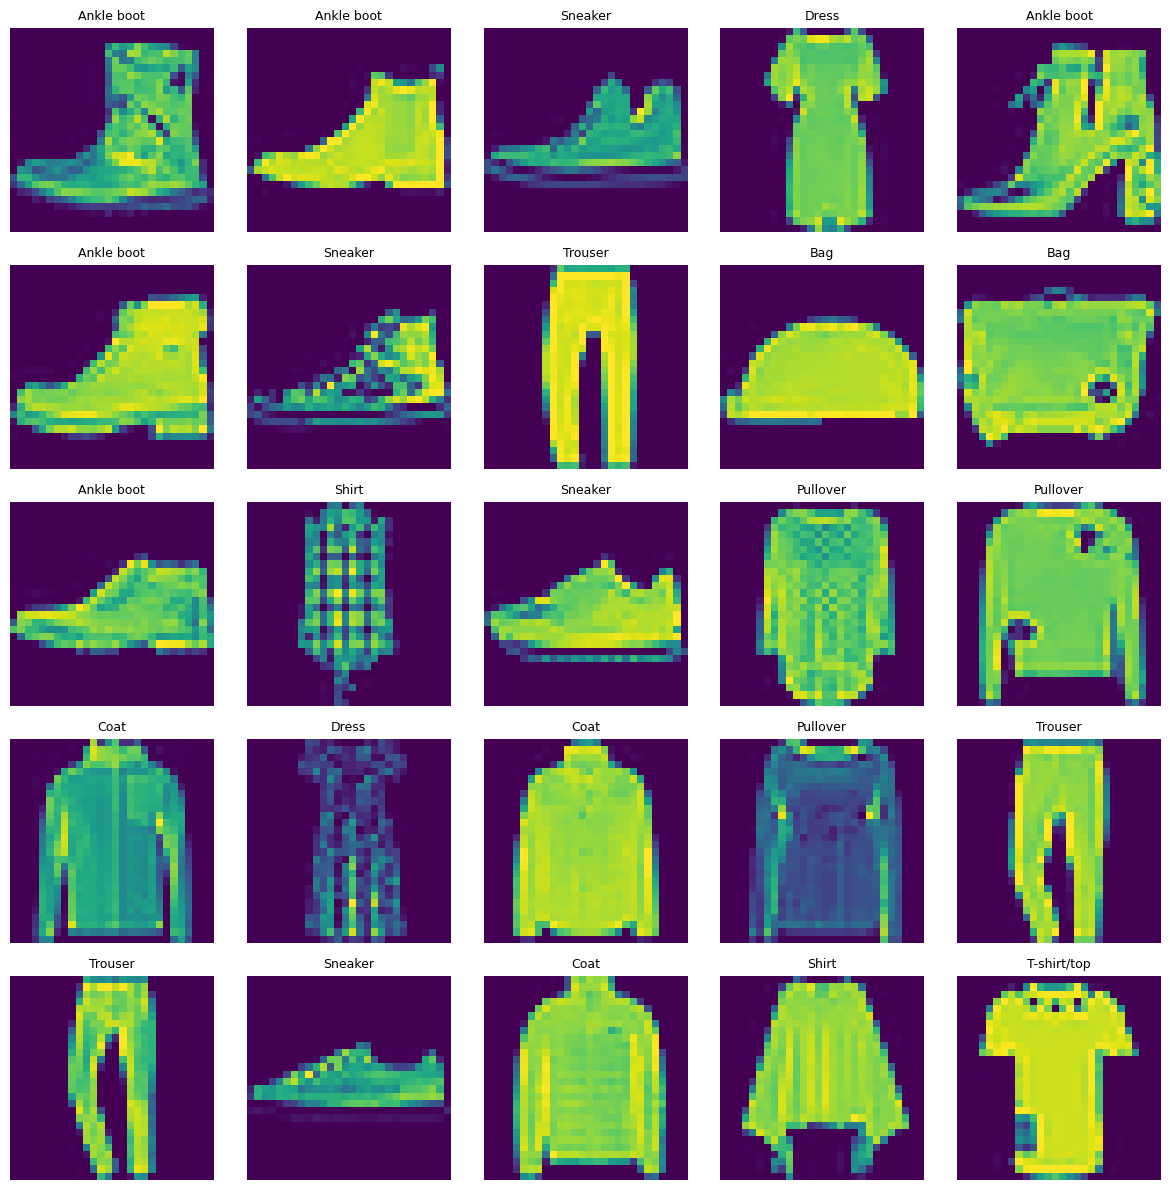

In [5]:
def  plot_image_grid(X, y, class_names, n_images=25, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images)))

    plt.figure(figsize=(12, 12))
    
    for plot_index, image_index in enumerate(indices):
        plt.subplot(grid_size, grid_size, plot_index + 1)
        plt.imshow(X[image_index])
        plt.title(class_names[y[image_index]], fontsize=9)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()


plot_image_grid(
    X_train_full,
    y_train_full,
    class_names,
    n_images=25
)

## Dataförståelse

Datasetet innehåller totalt **70 000 bilder**, där `X_train_full` består av **60 000 träningsbilder** och `X_test` av **10 000 testbilder**. Varje bild har storleken **28 × 28 pixlar**, och tillhörande etiketter finns i `y_train_full` och `y_test`.

Datasetet innehåller 10 klasser:

- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot

Varje klass innehåller **6000 bilder**, vilket innebär att datasetet är **balanserat** utan över- eller underrepresenterade klasser.

Baserat på de första 25 bilderna som visualiserades verkar även etiketteringen vara korrekt, då bilderna överensstämde med sina respektive klasser.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

print("X_train", X_train.shape)
print("X_val", X_val.shape)
print("X_test", X_test.shape)

X_train (54000, 28, 28)
X_val (6000, 28, 28)
X_test (10000, 28, 28)


In [7]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


print("Minsta värde efter normalisering:", X_train.min())
print("Största värde efter normalisering:", X_train.max())

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape efter kanal-dimension:", X_train.shape)
print("X_val shape efter kanal-dimension:", X_val.shape)
print("X_test shape efter kanal-dimension:", X_test.shape)

Minsta värde efter normalisering: 0.0
Största värde efter normalisering: 1.0
X_train shape efter kanal-dimension: (54000, 28, 28, 1)
X_val shape efter kanal-dimension: (6000, 28, 28, 1)
X_test shape efter kanal-dimension: (10000, 28, 28, 1)


## Förberedelse av data


### Dela upp träningsdata i träning och validering
Vi delar upp `X_train_full` och `y_train_full` i:

- **Träningsdata (X_train, y_train)**
- **Valideringsdata (X_val, y_val)**

Vi använder:
- 10% av datan som valideringsset (`test_size=0.10`)
- `stratify=y_train_full` för att behålla samma klassfördelning i båda delarna
- `random_state=42` för att få samma uppdelning varje gång

### Normalisering av pixelvärden
Vi konverterar bilderna till `float32` och skalar pixelvärden från:

- **0–255 → 0–1**

Detta görs för:
- snabbare och stabilare träning
- bättre numerisk stabilitet i modellen

Vi verifierar även att:
- minsta värde ≈ 0
- största värde ≈ 1

### Lägga till kanal-dimension
Eftersom bilderna är gråskaliga lägger vi till en extra dimension:

- Från: `(28, 28)`
- Till: `(28, 28, 1)`

Detta krävs för att neurala nätverk (t.ex. CNN) ska kunna behandla bilderna korrekt.

In [8]:
model = keras.Sequential()

model.add(layers.Input(shape=(28, 28, 1)))
model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

### Modellskapande 
Vi bygger en sekventiell modell med följande lager:

- Conv2D (32 filter, 3×3) — extraherar lokala mönster (kanter, texturer)
- MaxPooling2D (2×2) — minskar dimensionerna och behåller viktigaste informationen
- Conv2D (64 filter, 3×3) — extraherar mer komplexa mönster
- MaxPooling2D (2×2) — ytterligare dimensionsreduktion
- Flatten — gör om 2D-features till en 1D-vektor
- Dense (64 neuroner, ReLU) — lär sig kombinationer av features
- Dense (10 neuroner, softmax) — ger sannolikheter för varje klass (0–9)

Vi använder padding="same" för att behålla bildens dimensioner genom konvolutionslagren.

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

### Kompilering
Modellen kompileras med:

- Optimizer: Adam(learning_rate=0.001) -- adaptiv inlärning
- Loss: SparseCategoricalCrossentropy -- lämplig för flerklass-klassificering
- Metric: Accuracy -- andel korrekta klassificeringar

In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8342 - loss: 0.4607 - val_accuracy: 0.8695 - val_loss: 0.3615
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8931 - loss: 0.3009 - val_accuracy: 0.8873 - val_loss: 0.3122
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9081 - loss: 0.2560 - val_accuracy: 0.8938 - val_loss: 0.2974
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9190 - loss: 0.2253 - val_accuracy: 0.9023 - val_loss: 0.2756
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9278 - loss: 0.1999 - val_accuracy: 0.9043 - val_loss: 0.2734


### Träning
Modellen tränas med:

- 5 epoker -- varje epok går igenom hela träningsdatan en gång
- Batch size 64 -- uppdaterar vikterna efter varje batch
- Valideringsdata -- utvärderar modellen på osedd data efter varje epok

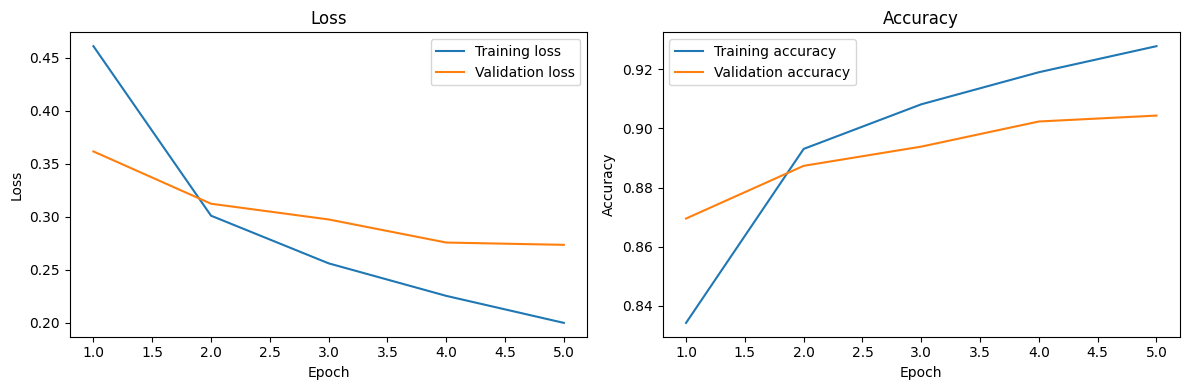

In [13]:
def plot_history(history):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) +1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Training accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

### Visualisering av träningshistorik
Vi plottar:

- Loss (träning vs validering) -- visar om modellen överanpassar
- Accuracy (träning vs validering) -- visar hur väl modellen generaliserar